In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import xgboost as xgb
import shap
import glob
import os
from datetime import timedelta
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

--- Fitting OLS Model ---
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               5.1773      4.632      1.118      0.267      -4.035      14.389
C(person)[T.이천수]        4.4277      3.786      1.169      0.246      -3.102      11.957
C(person)[T.임우일]        0.4159      4.369      0.095      0.924      -8.272       9.104
C(person)[T.장도연]       14.1659      4.369      3.243      0.002       5.478      22.854
C(person)[T.정유미]       -0.3401      4.378     -0.078      0.938      -9.047       8.366
C(day_of_week)[T.1]    10.0378      4.754      2.111      0.038       0.583      19.493
C(day_of_week)[T.2]     4.0472      4.859      0.833      0.407      -5.615      13.709
C(day_of_week)[T.3]     4.3138      4.762      0.906      0.368      -5.157      13.784
C(day_of_week)[T.4]     4.2289      4.687      0.902      0.370      -5.092      13.550
C(day_

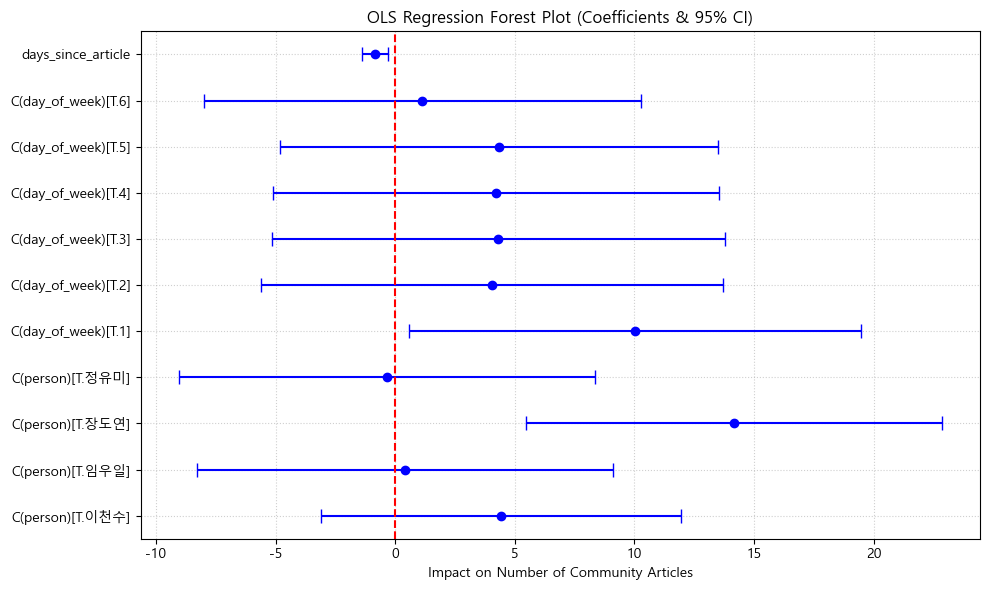


--- Fitting XGBoost Model ---


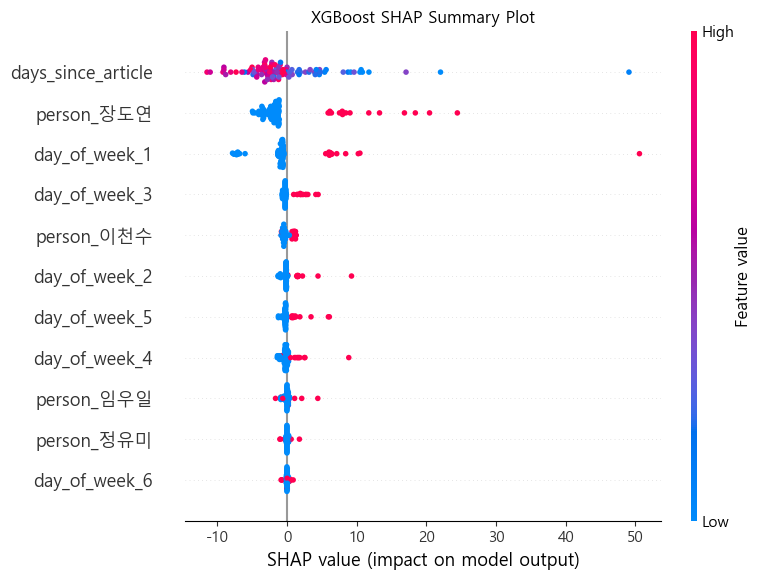


--- Model R-Squared Comparison ---
OLS R^2 (Full Data): 0.2682
XGB R^2 (Test Data): -1.3782


In [11]:
# Set up Korean font for Windows
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# File Paths (Ensure these match your local machine)
article_csv_path = r"C:\Users\WINDOWS 11\Desktop\kpop_agenda\Step2\name_article_time.csv"
list_files = glob.glob(r"C:\Users\WINDOWS 11\Desktop\kpop_agenda\Step2\*_list.csv")

# Load Article Times
articles_df = pd.read_csv(article_csv_path)
articles_df['article_time'] = pd.to_datetime(articles_df['article_time'], format='%Y-%m-%d-%H-%M')

# Load all Community Data
comm_list = []
for f in list_files:
    temp_df = pd.read_csv(f, usecols=['keyword', 'time'])
    comm_list.append(temp_df)
all_comm_df = pd.concat(comm_list, ignore_index=True)
all_comm_df['time'] = pd.to_datetime(all_comm_df['time'], format='%Y.%m.%d %H:%M')

# ==========================================
# 2. CONSTRUCT PANEL DATASET
# ==========================================
records = []

for idx, row in articles_df.iterrows():
    person = row['name']
    art_date = row['article_time'].normalize() 
    
    person_comm = all_comm_df[all_comm_df['keyword'] == person]
    daily_counts = person_comm.set_index('time').resample('D').size()
    
    # Track mentions for day 0 through 15
    for day_offset in range(16):
        target_date = art_date + timedelta(days=day_offset)
        y_count = daily_counts.get(target_date, 0)
        
        records.append({
            'event_id': f"{person}_Event_{idx+1}",
            'person': person,
            'days_since_article': day_offset,
            'day_of_week': target_date.weekday(), # 0=Mon, 6=Sun
            'mentions': y_count
        })

df_reg = pd.DataFrame(records)
df_reg['day_of_week'] = df_reg['day_of_week'].astype(str) 

# ==========================================
# 3. CLASSIC REGRESSION (OLS) & FOREST PLOT
# ==========================================
print("--- Fitting OLS Model ---")
ols_model = smf.ols('mentions ~ days_since_article + C(person) + C(day_of_week)', data=df_reg).fit()
print(ols_model.summary().tables[1])

# Forest Plot
plt.figure(figsize=(10, 6))
coefs = ols_model.params.drop('Intercept')
conf_ints = ols_model.conf_int().drop('Intercept')
errors = coefs - conf_ints[0]

plt.errorbar(coefs, coefs.index, xerr=errors, fmt='o', color='b', capsize=5)
plt.axvline(0, color='red', linestyle='--') 
plt.title('OLS Regression Forest Plot (Coefficients & 95% CI)')
plt.xlabel('Impact on Number of Community Articles')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# ==========================================
# 4. GRADIENT BOOSTING (XGBoost) & SHAP
# ==========================================
print("\n--- Fitting XGBoost Model ---")

# FIX 1: .astype(float) prevents the SHAP TypeError
X = pd.get_dummies(df_reg[['days_since_article', 'person', 'day_of_week']], drop_first=True).astype(float)
y = df_reg['mentions']

# FIX 2: Train/Test split prevents the 0.99 R^2 Overfitting issue
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=3, random_state=42)
xgb_model.fit(X_train, y_train)

# SHAP Plot (Visualizing the impact on the entire dataset for full context)
explainer = shap.Explainer(xgb_model, X)
shap_values = explainer(X)

plt.figure(figsize=(10, 6))
plt.title("XGBoost SHAP Summary Plot")
shap.summary_plot(shap_values, X, show=False)
plt.tight_layout()
plt.show()

# ==========================================
# 5. FINAL R-SQUARED COMPARISON
# ==========================================
xgb_predictions = xgb_model.predict(X_test)

print("\n--- Model R-Squared Comparison ---")
print(f"OLS R^2 (Full Data): {ols_model.rsquared:.4f}")
print(f"XGB R^2 (Test Data): {r2_score(y_test, xgb_predictions):.4f}")